In [1]:
"""Active Field Estimation with Max Variance Sampling vs Uniform Random."""

import sys
from pathlib import Path


def add_project_root_to_path() -> Path:
    """Add repository root to sys.path. Works for both scripts and Jupyter notebooks."""
    if getattr(sys.modules.get("__main__", None), "__file__", None):
        # Script: project root is 3 levels up from experiments/field_estimation/scripts/*.py
        project_root = Path(sys.modules["__main__"].__file__).resolve().parents[3]
    else:
        # Notebook: walk up from cwd until we find project root (has src/ and pixi.toml)
        project_root = Path.cwd()
        for _ in range(10):
            if (project_root / "src").is_dir() and (project_root / "pixi.toml").exists():
                break
            parent = project_root.parent
            if parent == project_root:
                raise FileNotFoundError("Project root (directory with src/ and pixi.toml) not found.")
            project_root = parent
    root_str = str(project_root)
    if root_str not in sys.path:
        sys.path.insert(0, root_str)
    return project_root


add_project_root_to_path()

import jax
from jax import config


config.update("jax_enable_x64", True)

import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import gpjax as gpx
import optax as ox

from src.env.field.rff_gp_field import RFFGPField
from src.env.utils.types import GridConfig, GridPosition
from experiments.field_estimation.utils.evaluation import compute_field_rmse

In [2]:
# 1. Setup True Field
# ===================
grid_size = 50
sigma_true = 5.0
lengthscale_true = 7.5
nu_true = 2.5
noise_std_true = 0.2

seed = 42
key = jr.PRNGKey(seed)
key, field_key = jr.split(key)

grid_config = GridConfig.create(n_x=grid_size, n_y=grid_size)
field = RFFGPField(
    config=grid_config,
    d_max=4 * sigma_true,
    sigma=sigma_true,
    lengthscale=lengthscale_true,
    nu=nu_true,
    noise_std=noise_std_true,
)
field.reset(field_key)

true_u = field._precomputed_u.squeeze()  # shape (50, 50)

# Setup Test Grid for predictions and candidate generation
x_coords = jnp.arange(1, grid_size + 1)
y_coords = jnp.arange(1, grid_size + 1)
Xm, Ym = jnp.meshgrid(x_coords, y_coords, indexing="ij")
X_test = jnp.column_stack([Xm.ravel(), Ym.ravel()]).astype(jnp.float64)

M = 500
var_init = sigma_true**2
lengthscale_init = lengthscale_true

W0313 14:37:43.833140 2960900 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


In [3]:
# 2. General Evaluation Function
# ==============================
def evaluate_gp(X_tr, y_tr, var_init=1.0, lengthscale_init=1.0, optimize=False):
    """Fit GP and return predictions and RMSE. Optionally optimize hyperparams."""
    dataset = gpx.Dataset(X=X_tr, y=y_tr)

    if optimize:
        kernel = gpx.kernels.Matern52(variance=var_init, lengthscale=lengthscale_init)
        prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
        likelihood = gpx.likelihoods.Gaussian(
            num_datapoints=dataset.n, obs_stddev=jnp.array([0.5])
        )
        posterior = prior * likelihood

        nmll = lambda p, d: -gpx.objectives.conjugate_mll(p, d)
        optim = ox.adam(learning_rate=0.05)
        opt_posterior, _ = gpx.fit(
            model=posterior,
            objective=nmll,
            train_data=dataset,
            optim=optim,
            num_iters=300,
        )

        v_opt = float(opt_posterior.prior.kernel.variance[...])
        l_opt = float(opt_posterior.prior.kernel.lengthscale[...])
        n_opt = float(opt_posterior.likelihood.obs_stddev[...][0])

        latent_dist = opt_posterior.predict(X_test, train_data=dataset)
    else:
        kernel = gpx.kernels.Matern52(variance=var_init, lengthscale=lengthscale_init)
        prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
        likelihood = gpx.likelihoods.Gaussian(
            num_datapoints=dataset.n, obs_stddev=jnp.array([noise_std_true])
        )
        posterior = prior * likelihood

        v_opt, l_opt, n_opt = var_init, lengthscale_init, noise_std_true
        latent_dist = posterior.predict(X_test, train_data=dataset)

    mu = latent_dist.mean.reshape(grid_size, grid_size)
    var = latent_dist.variance.reshape(grid_size, grid_size)
    rmse_val = jnp.sqrt(jnp.mean((true_u - mu) ** 2))

    return mu, var, float(rmse_val), (v_opt, l_opt, n_opt)

In [5]:
# 3. Collect Uniform Random Observations
# ======================================
key, sample_key = jr.split(key)

print(f"Collecting {M} Uniform Random samples...")
i_idx_rand = jr.randint(sample_key, (M,), 1, grid_size + 1)
sample_key, _ = jr.split(sample_key)
j_idx_rand = jr.randint(sample_key, (M,), 1, grid_size + 1)

X_train_rand = jnp.column_stack([i_idx_rand, j_idx_rand]).astype(jnp.float64)
y_train_rand = jnp.zeros((M, 1))

key, noise_key = jr.split(key)
noise_keys_rand = jr.split(noise_key, M)

for idx in range(M):
    pos = GridPosition(int(X_train_rand[idx, 0]), int(X_train_rand[idx, 1]))
    disp = field.sample_displacement(pos, noise_keys_rand[idx])
    y_train_rand = y_train_rand.at[idx, 0].set(disp.u)

In [6]:
# 4. Collect Active Observations (Max Variance)
# =============================================
b = 1  # Batch size
initial_samples = 50

X_train_act_list = []
y_train_act_list = []
key, sample_key = jr.split(key)

# 4.1 Initial Random Sample
i_idx_act = jr.randint(sample_key, (initial_samples,), 1, grid_size + 1)
sample_key, _ = jr.split(sample_key)
j_idx_act = jr.randint(sample_key, (initial_samples,), 1, grid_size + 1)
X_init_act = jnp.column_stack([i_idx_act, j_idx_act]).astype(jnp.float64)

for idx in range(initial_samples):
    key, noise_key = jr.split(key)
    pos = GridPosition(int(X_init_act[idx, 0]), int(X_init_act[idx, 1]))
    disp = field.sample_displacement(pos, noise_key)
    X_train_act_list.append(X_init_act[idx])
    y_train_act_list.append(jnp.array([disp.u]))

X_train_act = jnp.array(X_train_act_list)
y_train_act = jnp.array(y_train_act_list)

active_rmse_history = []
active_sample_counts = []

print(f"\nStarting active learning... (Target M={M}, batch size={b})")

# Evaluate Initial
mu_act, var_act, rmse_act, _ = evaluate_gp(
    X_train_act, y_train_act, var_init, lengthscale_init, optimize=False
)
active_rmse_history.append(rmse_act)
active_sample_counts.append(len(X_train_act))
print(f"Collected {len(X_train_act):<3}/{M} samples | RMSE = {rmse_act:.4f}")

while len(X_train_act) < M:
    # Select top b locations with max variance
    top_indices = jnp.argsort(var_act.flatten())[-b:]
    X_batch = X_test[top_indices]

    for idx in range(b):
        key, noise_key = jr.split(key)
        pos = GridPosition(int(X_batch[idx, 0]), int(X_batch[idx, 1]))
        disp = field.sample_displacement(pos, noise_key)
        X_train_act_list.append(X_batch[idx])
        y_train_act_list.append(jnp.array([disp.u]))

    X_train_act = jnp.array(X_train_act_list)
    y_train_act = jnp.array(y_train_act_list)

    # Evaluate new dataset to update variance for next iteration and track RMSE
    mu_act, var_act, rmse_act, _ = evaluate_gp(
        X_train_act, y_train_act, var_init, lengthscale_init, optimize=False
    )

    active_rmse_history.append(rmse_act)
    active_sample_counts.append(len(X_train_act))
    print(f"Collected {len(X_train_act):<3}/{M} samples | RMSE = {rmse_act:.4f}")


Starting active learning... (Target M=500, batch size=1)
Collected 50 /500 samples | RMSE = 2.5498
Collected 51 /500 samples | RMSE = 2.3727
Collected 52 /500 samples | RMSE = 2.3720
Collected 53 /500 samples | RMSE = 2.3707
Collected 54 /500 samples | RMSE = 2.3708
Collected 55 /500 samples | RMSE = 2.3699
Collected 56 /500 samples | RMSE = 2.3532
Collected 57 /500 samples | RMSE = 2.3514
Collected 58 /500 samples | RMSE = 2.1540
Collected 59 /500 samples | RMSE = 2.1001
Collected 60 /500 samples | RMSE = 2.1001
Collected 61 /500 samples | RMSE = 2.0709
Collected 62 /500 samples | RMSE = 1.6199
Collected 63 /500 samples | RMSE = 1.6195
Collected 64 /500 samples | RMSE = 1.5728
Collected 65 /500 samples | RMSE = 1.5336
Collected 66 /500 samples | RMSE = 1.5350
Collected 67 /500 samples | RMSE = 1.5326
Collected 68 /500 samples | RMSE = 1.4919
Collected 69 /500 samples | RMSE = 1.4944
Collected 70 /500 samples | RMSE = 1.4485
Collected 71 /500 samples | RMSE = 1.4476
Collected 72 /500 

In [7]:
# 5. Final Evaluation (True Parameters)
# =====================================
print("\nEvaluating Final Random Dataset...")
mu_rand, var_rand, rmse_rand, _ = evaluate_gp(
    X_train_rand, y_train_rand, var_init, lengthscale_init, optimize=False
)

print("Evaluating Final Active Dataset...")
mu_act_final, var_act_final, rmse_act_final, _ = evaluate_gp(
    X_train_act, y_train_act, var_init, lengthscale_init, optimize=False
)


Evaluating Final Random Dataset...
Evaluating Final Active Dataset...


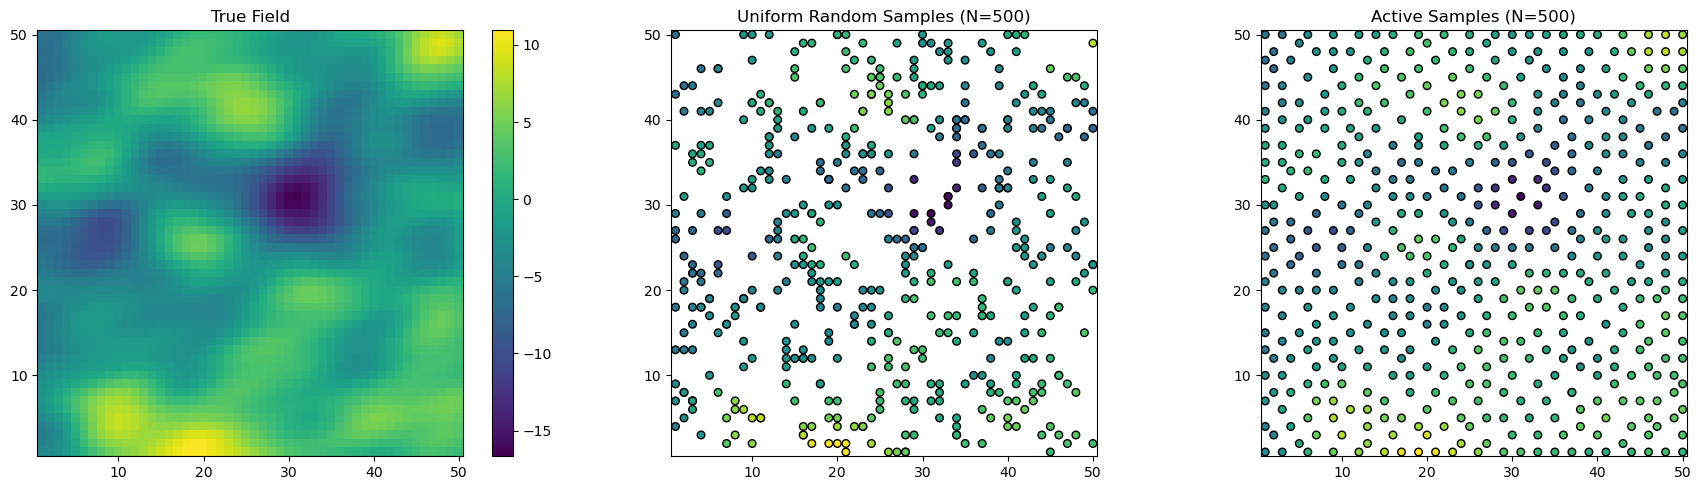

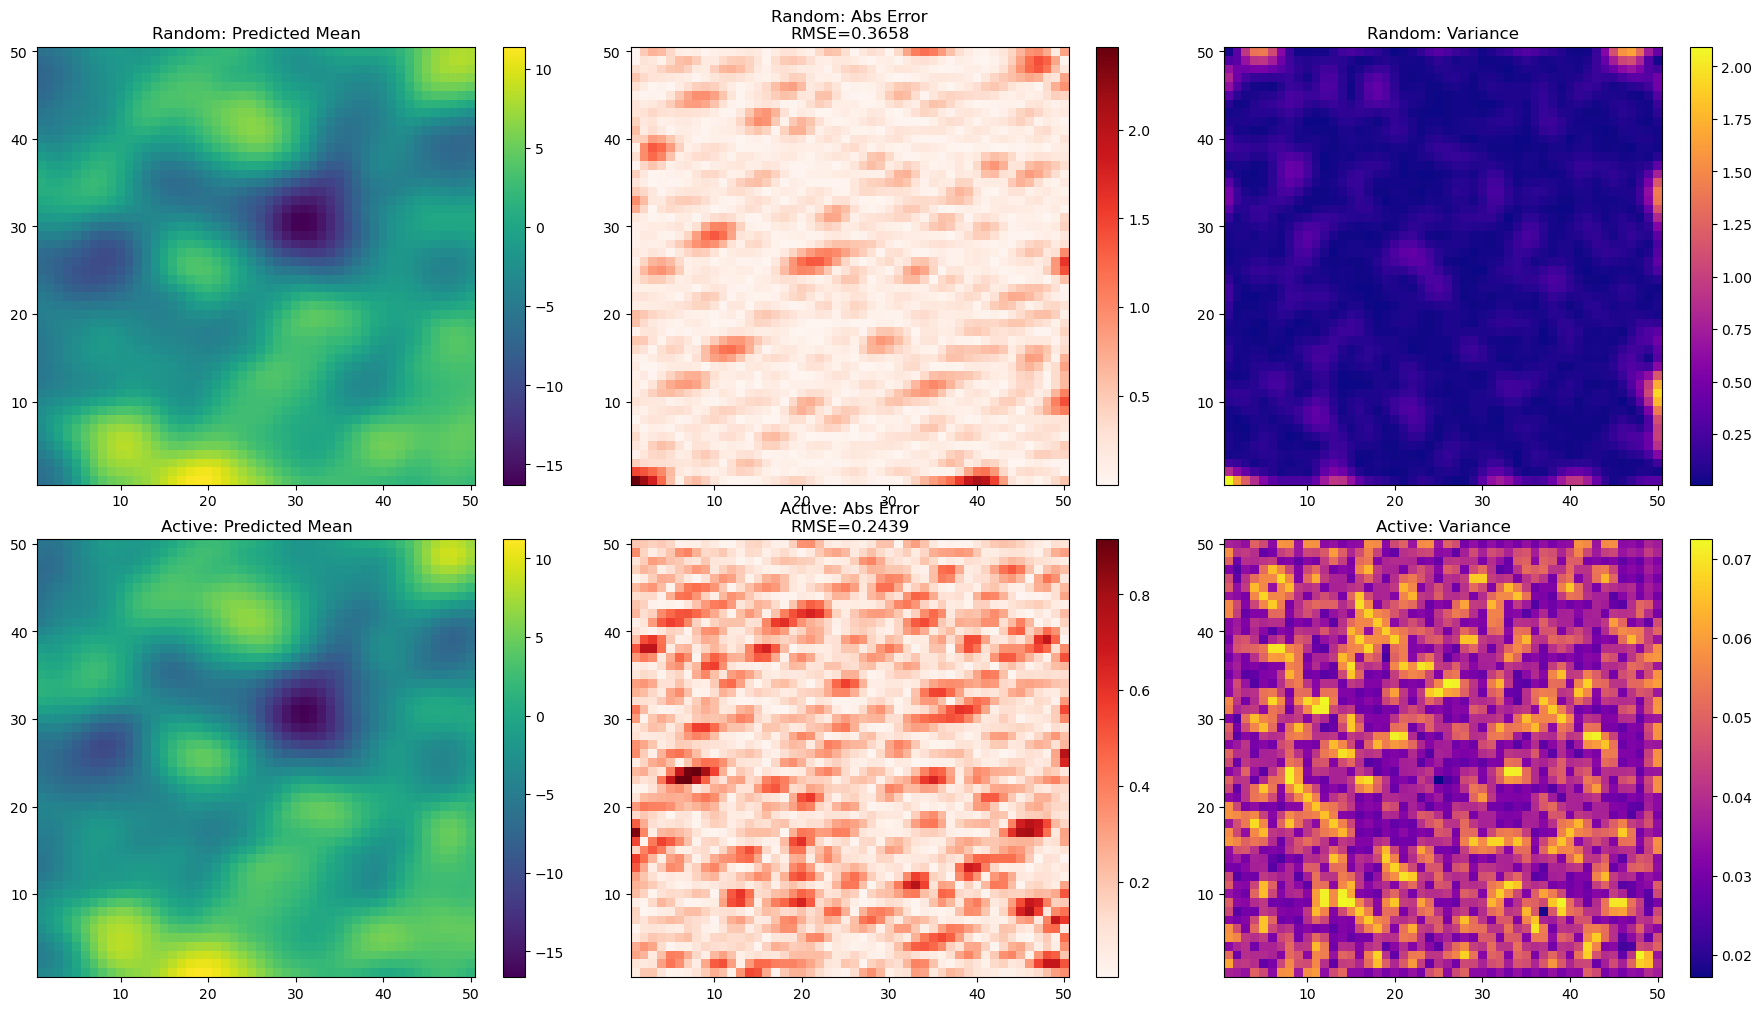

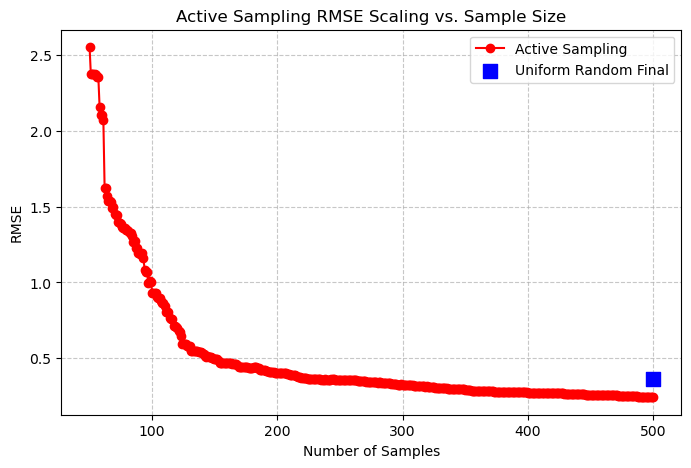

In [8]:
# 6. Plotting
# ===========

# Figure 1: True Field & Sample Heatmaps (1x3)
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes1[0].imshow(
    true_u.T,
    origin="lower",
    cmap="viridis",
    extent=[0.5, grid_size + 0.5, 0.5, grid_size + 0.5],
)
axes1[0].set_title("True Field")
plt.colorbar(im0, ax=axes1[0])

axes1[1].scatter(
    X_train_rand[:, 0],
    X_train_rand[:, 1],
    c=y_train_rand[:, 0],
    cmap="viridis",
    edgecolors="k",
    s=30,
)
axes1[1].set_xlim(0.5, grid_size + 0.5)
axes1[1].set_ylim(0.5, grid_size + 0.5)
axes1[1].set_title(f"Uniform Random Samples (N={M})")
axes1[1].set_aspect("equal")

axes1[2].scatter(
    X_train_act[:, 0],
    X_train_act[:, 1],
    c=y_train_act[:, 0],
    cmap="viridis",
    edgecolors="k",
    s=30,
)
axes1[2].set_xlim(0.5, grid_size + 0.5)
axes1[2].set_ylim(0.5, grid_size + 0.5)
axes1[2].set_title(f"Active Samples (N={M})")
axes1[2].set_aspect("equal")

plt.tight_layout()
plt.savefig("plots/active_estimation/active_estimation_sample_heatmaps.png")
plt.show()


# Figure 2: Random vs Active GP Posteriors (2x3)
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Random
im_r1 = axes2[0, 0].imshow(
    mu_rand.T,
    origin="lower",
    cmap="viridis",
    extent=[0.5, grid_size + 0.5, 0.5, grid_size + 0.5],
)
axes2[0, 0].set_title("Random: Predicted Mean")
plt.colorbar(im_r1, ax=axes2[0, 0])

err_rand = jnp.abs(true_u - mu_rand)
im_r2 = axes2[0, 1].imshow(
    err_rand.T,
    origin="lower",
    cmap="Reds",
    extent=[0.5, grid_size + 0.5, 0.5, grid_size + 0.5],
)
axes2[0, 1].set_title(f"Random: Abs Error\nRMSE={rmse_rand:.4f}")
plt.colorbar(im_r2, ax=axes2[0, 1])

im_r3 = axes2[0, 2].imshow(
    var_rand.T,
    origin="lower",
    cmap="plasma",
    extent=[0.5, grid_size + 0.5, 0.5, grid_size + 0.5],
)
axes2[0, 2].set_title("Random: Variance")
plt.colorbar(im_r3, ax=axes2[0, 2])

# Row 2: Active
im_a1 = axes2[1, 0].imshow(
    mu_act_final.T,
    origin="lower",
    cmap="viridis",
    extent=[0.5, grid_size + 0.5, 0.5, grid_size + 0.5],
)
axes2[1, 0].set_title("Active: Predicted Mean")
plt.colorbar(im_a1, ax=axes2[1, 0])

err_act = jnp.abs(true_u - mu_act_final)
im_a2 = axes2[1, 1].imshow(
    err_act.T,
    origin="lower",
    cmap="Reds",
    extent=[0.5, grid_size + 0.5, 0.5, grid_size + 0.5],
)
axes2[1, 1].set_title(f"Active: Abs Error\nRMSE={rmse_act_final:.4f}")
plt.colorbar(im_a2, ax=axes2[1, 1])

im_a3 = axes2[1, 2].imshow(
    var_act_final.T,
    origin="lower",
    cmap="plasma",
    extent=[0.5, grid_size + 0.5, 0.5, grid_size + 0.5],
)
axes2[1, 2].set_title("Active: Variance")
plt.colorbar(im_a3, ax=axes2[1, 2])

plt.tight_layout()
plt.savefig("plots/active_estimation/active_estimation_gp_posteriors.png")
plt.show()

# Figure 3: RMSE Scaling during Active Collection
plt.figure(figsize=(8, 5))
plt.plot(
    active_sample_counts,
    active_rmse_history,
    marker="o",
    linestyle="-",
    color="r",
    label="Active Sampling",
)
# Also plot the final Random RMSE as a reference point
plt.scatter(
    [M],
    [rmse_rand],
    color="b",
    marker="s",
    s=100,
    zorder=5,
    label="Uniform Random Final",
)
plt.xlabel("Number of Samples")
plt.ylabel("RMSE")
plt.title("Active Sampling RMSE Scaling vs. Sample Size")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.savefig("plots/active_estimation/active_estimation_rmse_scaling.png")
plt.show()